# Задание 1

mu = 2.6458, sigma = 6.1500
Радиус 3-sigma: 18.4500
Точек внутри окружности 3-sigma: 99 из 100 (99.0%)
Теоретический радиус для 99%: 18.6644
Точек внутри теоретической 99%-окружности: 99 из 100 (99.0%)
Эмпирический 99-й процентиль расстояний: 14.4989


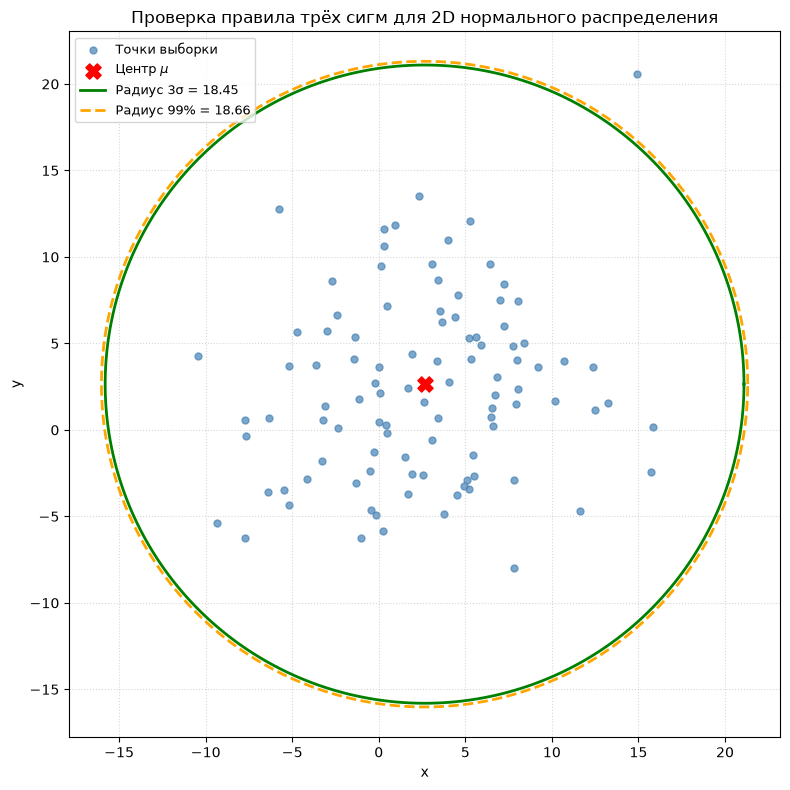

In [1]:
import matplotlib as plt

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2


# --- Параметры распределения ---
mu = np.sqrt(7)      # мат. ожидание (одинаковое по обеим координатам)
sigma = 6.15          # среднее квадратическое отклонение
n_points = 100

rng = np.random.default_rng(42)  # фиксируем seed для воспроизводимости

# --- Генерация выборки: 100 точек размерности 2 ---
# Каждая точка (x, y), где x ~ N(mu, sigma^2), y ~ N(mu, sigma^2), независимо
points = rng.normal(loc=mu, scale=sigma, size=(n_points, 2))
center = np.array([mu, mu])

# --- Расстояния точек от центра mu ---
distances = np.linalg.norm(points - center, axis=1)

# --- Радиус окружности "3 сигма" ---
r_3sigma = 3 * sigma

# --- Радиус окружности, охватывающей 99% точек ---
# Для изотропного 2D нормального распределения расстояние r = sigma * sqrt(chi2),
# где chi2 имеет распределение хи-квадрат с 2 степенями свободы.
# Радиус, накрывающий долю p точек теоретически:
r_99_theory = sigma * np.sqrt(chi2.ppf(0.99, df=2))

# Эмпирический радиус (99-й процентиль реальных расстояний в выборке)
r_99_empirical = np.percentile(distances, 99)

# --- Проверка правила трёх сигм ---
inside_3sigma = np.sum(distances <= r_3sigma)
inside_99_theory = np.sum(distances <= r_99_theory)

print(f"mu = {mu:.4f}, sigma = {sigma:.4f}")
print(f"Радиус 3-sigma: {r_3sigma:.4f}")
print(f"Точек внутри окружности 3-sigma: {inside_3sigma} из {n_points} "
      f"({inside_3sigma/n_points*100:.1f}%)")
print(f"Теоретический радиус для 99%: {r_99_theory:.4f}")
print(f"Точек внутри теоретической 99%-окружности: {inside_99_theory} из {n_points} "
      f"({inside_99_theory/n_points*100:.1f}%)")
print(f"Эмпирический 99-й процентиль расстояний: {r_99_empirical:.4f}")

# --- Визуализация ---
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(points[:, 0], points[:, 1], s=25, color="steelblue",
           alpha=0.7, label="Точки выборки")
ax.scatter(*center, color="red", s=120, marker="X", zorder=5,
           label=r"Центр $\mu$")

theta = np.linspace(0, 2 * np.pi, 300)

# Окружность 3-сигма
ax.plot(center[0] + r_3sigma * np.cos(theta),
        center[1] + r_3sigma * np.sin(theta),
        color="green", linewidth=2, label=f"Радиус 3σ = {r_3sigma:.2f}")

# Окружность 99% (теоретическая)
ax.plot(center[0] + r_99_theory * np.cos(theta),
        center[1] + r_99_theory * np.sin(theta),
        color="orange", linewidth=2, linestyle="--",
        label=f"Радиус 99% = {r_99_theory:.2f}")

ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Проверка правила трёх сигм для 2D нормального распределения")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()

# Задание 2

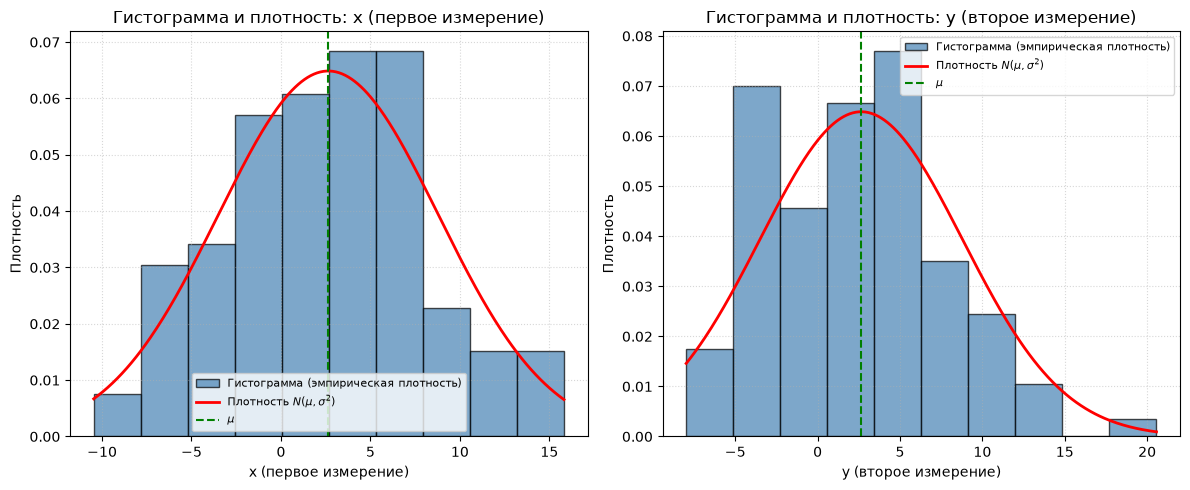

In [2]:
from scipy.stats import norm

# --- Параметры распределения (те же, что и в первом задании) ---
n_bins = 10

x = points[:, 0]
y = points[:, 1]

labels = ["x (первое измерение)", "y (второе измерение)"]
data = [x, y]

plt.figure(figsize=(12, 5))

for i in range(2):
    plt.subplot(1, 2, i + 1)

    # Гистограмма: density=True, чтобы ось соответствовала плотности вероятности,
    # а не абсолютной частоте -- иначе кривую плотности накладывать некорректно
    counts, bins, patches = plt.hist(
        data[i], bins=n_bins, density=True,
        color="steelblue", alpha=0.7, edgecolor="black",
        label="Гистограмма (эмпирическая плотность)"
    )

    # Кривая теоретической плотности N(mu, sigma^2)
    x_grid = np.linspace(bins[0], bins[-1], 300)
    pdf = norm.pdf(x_grid, loc=mu, scale=sigma)
    plt.plot(x_grid, pdf, color="red", linewidth=2,
             label=r"Плотность $N(\mu,\sigma^2)$")

    plt.axvline(mu, color="green", linestyle="--", linewidth=1.5, label=r"$\mu$")

    plt.title(f"Гистограмма и плотность: {labels[i]}")
    plt.xlabel(labels[i])
    plt.ylabel("Плотность")
    plt.legend(fontsize=8)
    plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()

# Задание 3

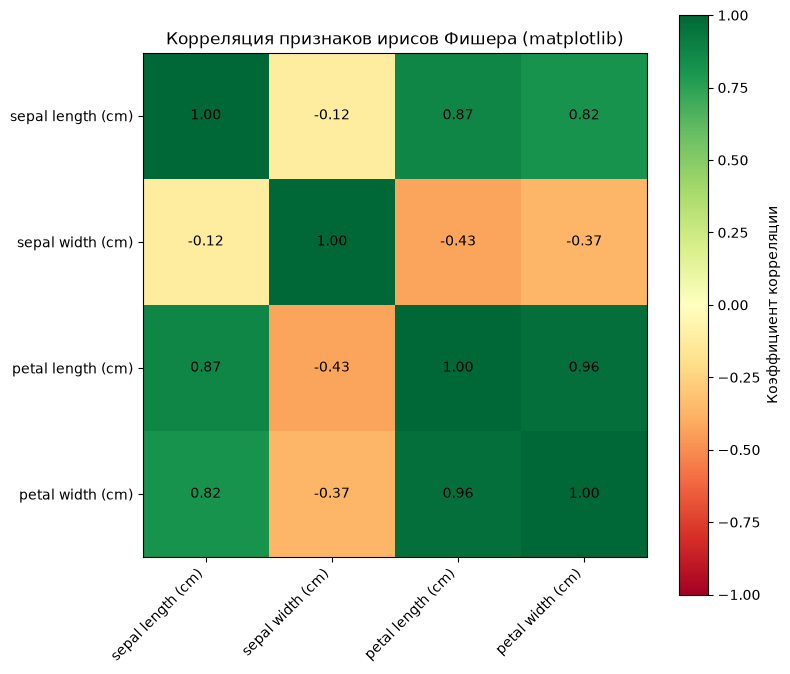

In [3]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
corr = df.corr()

# matplotlib
plt.figure(figsize=(8, 7))
im = plt.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, label="Коэффициент корреляции")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Корреляция признаков ирисов Фишера (matplotlib)")
plt.tight_layout()
plt.show()

# Задание 4

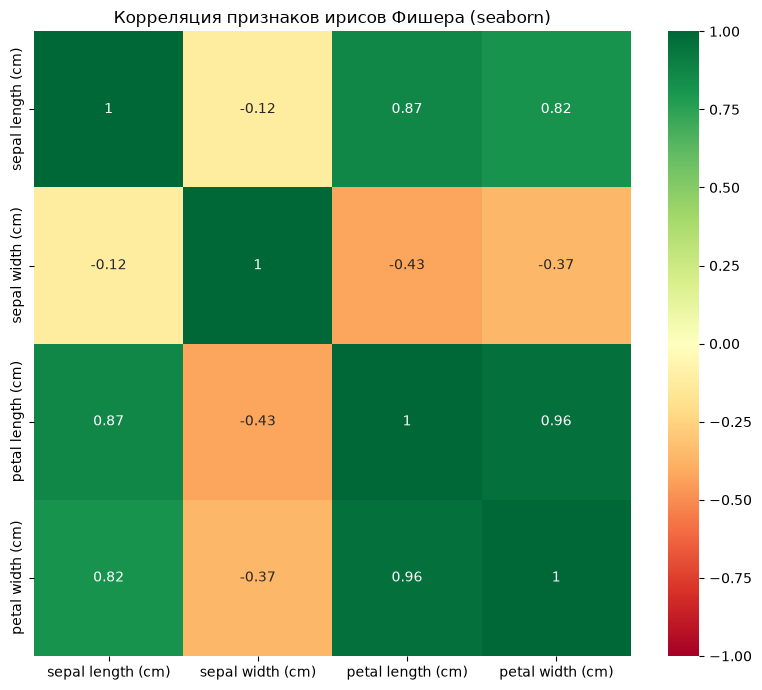

In [4]:
# seaborn
plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, cmap="RdYlGn", vmin=-1, vmax=1,
            xticklabels=corr.columns, yticklabels=corr.columns)
plt.title("Корреляция признаков ирисов Фишера (seaborn)")
plt.tight_layout()
plt.show()